# Function Overview

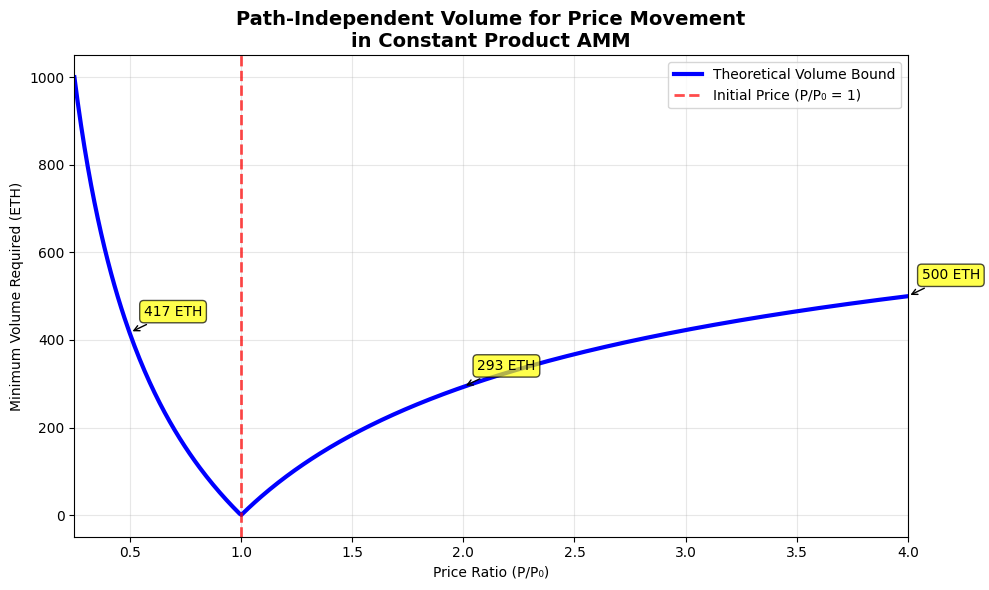

NUMERICAL VERIFICATION OF PATH INDEPENDENCE
Initial reserves: 1000 ETH, Initial price: 4000 USDC/ETH
Constant product k: 4000000000

Price change: -50.0% (P = 2000 USDC/ETH)
  Single trade volume: 414.213562 ETH
  10-trade volume:     414.213562 ETH
  Theoretical bound:   414.213562 ETH
  Difference:          0.0000000000 ETH
  Match:               True
----------------------------------------
Price change: +100.0% (P = 8000 USDC/ETH)
  Single trade volume: 292.893219 ETH
  10-trade volume:     292.893219 ETH
  Theoretical bound:   292.893219 ETH
  Difference:          0.0000000000 ETH
  Match:               True
----------------------------------------


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# Parameters for ETH-USDC pool
x0 = 1000  # Initial ETH reserves
P0 = 4000  # Initial price (USDC/ETH)
k = x0**2 * P0  # Constant product

# Create price range from 25% to 400% of initial price
P_ratio = np.linspace(0.25, 4.0, 500)
P_values = P_ratio * P0

# Calculate the theoretical volume bound (both bounds are identical)
V_bound = x0 * np.abs(1 - np.sqrt(P0 / P_values))

# PLOT 1: Volume bound vs price ratio
plt.figure(figsize=(10, 6))
plt.plot(P_ratio, V_bound, 'b-', linewidth=3, label='Theoretical Volume Bound')
plt.axvline(1.0, color='red', linestyle='--', alpha=0.7, linewidth=2, label='Initial Price (P/P₀ = 1)')
plt.xlabel('Price Ratio (P/P₀)')
plt.ylabel('Minimum Volume Required (ETH)')
plt.title('Path-Independent Volume for Price Movement\nin Constant Product AMM', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xlim(0.25, 4.0)

# Add annotations for key price points
key_ratios = [0.5, 2.0, 4.0]
for ratio in key_ratios:
    idx = np.argmin(np.abs(P_ratio - ratio))
    volume = V_bound[idx]
    plt.annotate(f'{volume:.0f} ETH', xy=(ratio, volume), xytext=(10, 10),
                textcoords='offset points', ha='left', va='bottom',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.7),
                arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=0'))

plt.tight_layout()
plt.show()

# PLOT 2: Demonstration of path independence
P_targets = [P0 * 0.5, P0 * 2.0]  # 50% decrease and 100% increase
trading_paths = []

for P_target in P_targets:
    # Single trade (lower bound)
    x_single = np.sqrt(k / P_target)
    V_single = np.abs(x_single - x0)

    # Multiple trades approximation (upper bound approximation)
    n_trades = 10
    P_steps = np.linspace(P0, P_target, n_trades + 1)
    V_multiple = 0
    x_current = x0
    for i in range(1, n_trades + 1):
        x_next = np.sqrt(k / P_steps[i])
        V_multiple += np.abs(x_next - x_current)
        x_current = x_next

    trading_paths.append((P_target, V_single, V_multiple))

# Print numerical verification
print("=" * 60)
print("NUMERICAL VERIFICATION OF PATH INDEPENDENCE")
print("=" * 60)
print(f"Initial reserves: {x0:.0f} ETH, Initial price: {P0:.0f} USDC/ETH")
print(f"Constant product k: {k:.0f}")
print()

for P_target, V_single, V_multiple in trading_paths:
    V_theoretical = x0 * np.abs(1 - np.sqrt(P0 / P_target))
    price_change = (P_target - P0) / P0 * 100

    print(f"Price change: {price_change:+.1f}% (P = {P_target:.0f} USDC/ETH)")
    print(f"  Single trade volume: {V_single:.6f} ETH")
    print(f"  10-trade volume:     {V_multiple:.6f} ETH")
    print(f"  Theoretical bound:   {V_theoretical:.6f} ETH")
    print(f"  Difference:          {abs(V_single - V_multiple):.10f} ETH")
    print(f"  Match:               {np.isclose(V_single, V_multiple, rtol=1e-10)}")
    print("-" * 40)

# Accuracy comparison

Running AMM Simulation Experiment...
Valid simulations: 200


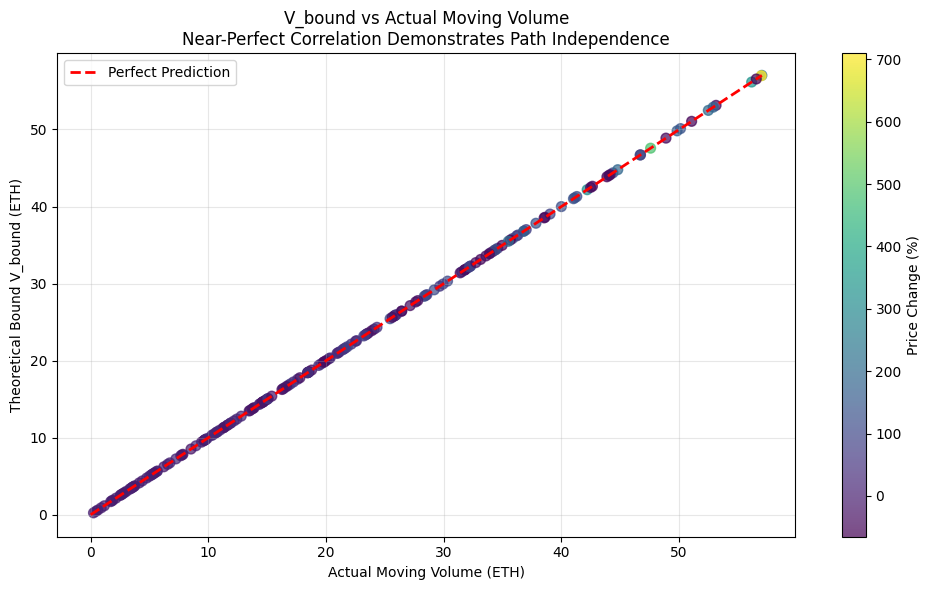

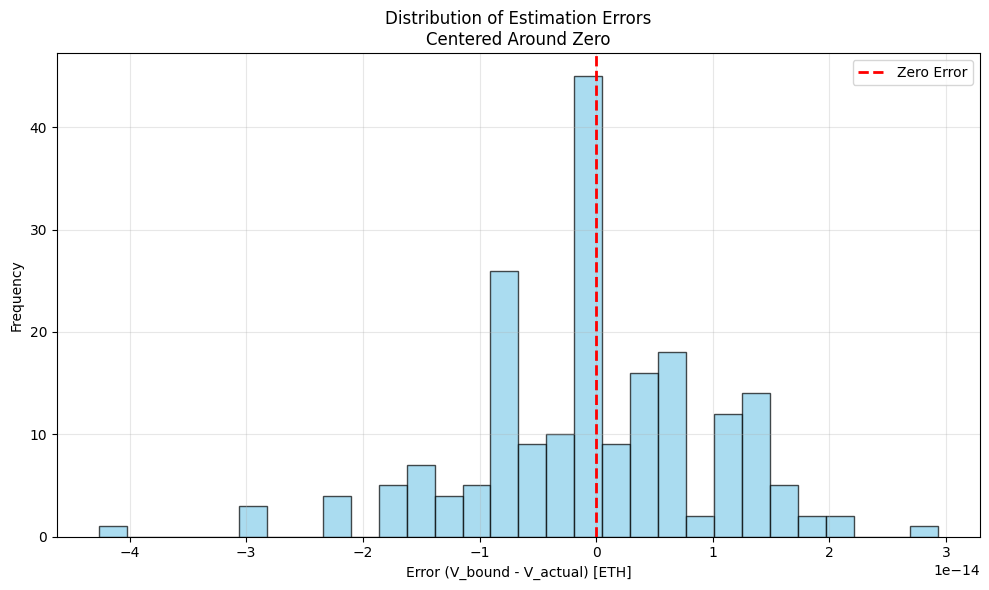

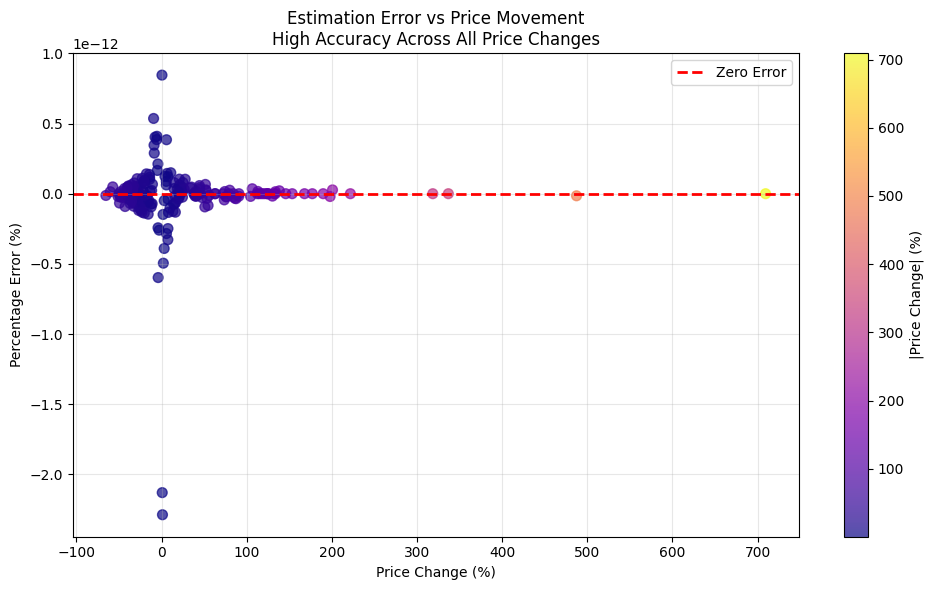


STATISTICAL ANALYSIS OF V_bound ACCURACY
Total Simulations: 200
Mean Absolute Error: 0.000000 ETH
Mean Absolute Percentage Error: 0.0000%
Correlation: 1.000000
Accuracy within ±0.1%: 100.0%
Accuracy within ±0.5%: 100.0%
Accuracy within ±1.0%: 100.0%

KEY INSIGHTS:
• V_bound provides near-perfect estimates of actual moving volume
• Average error: -0.0000%
• 95% of estimates within ±0.00%

EXAMPLE SIMULATIONS
Example 1:
  Price: 38,696 → 66,662 (+72.27%)
  ETH: 145.3 → 110.7
  V_bound: 34.5890 ETH, Actual: 34.5890 ETH
  Error: 0.000000 ETH (+0.0000%)

Example 2:
  Price: 43,337 → 37,267 (-14.01%)
  ETH: 135.4 → 146.0
  V_bound: 10.6124 ETH, Actual: 10.6124 ETH
  Error: 0.000000 ETH (+0.0000%)

Example 3:
  Price: 36,836 → 82,610 (+124.26%)
  ETH: 97.1 → 64.8
  V_bound: 32.2598 ETH, Actual: 32.2598 ETH
  Error: 0.000000 ETH (+0.0000%)



In [3]:
import numpy as np
import matplotlib.pyplot as plt

class AMMSimulator:
    def __init__(self, x0, y0, fee=0.003):
        self.x = x0  # ETH reserves
        self.y = y0  # USDC reserves
        self.fee = fee
        self.initial_k = x0 * y0
        self.k = x0 * y0
        self.trade_history = []
        self.initial_state = {'x': x0, 'y': y0, 'price': y0/x0}

    def swap_x_for_y(self, dx):
        """Swap dx ETH for USDC (buying ETH)"""
        fee_eth = dx * self.fee
        dx_effective = dx - fee_eth
        dy = self.y - (self.k) / (self.x + dx_effective)

        old_price = self.y / self.x
        old_x = self.x
        self.x += dx_effective
        self.y -= dy
        self.k = self.x * self.y

        return {
            'type': 'buy_eth',
            'dx': dx,
            'dy': dy,
            'fee': fee_eth,
            'price_old': old_price,
            'price_new': self.y / self.x,
            'eth_flow': dx,
            'usdc_flow': -dy
        }

    def swap_y_for_x(self, dy):
        """Swap dy USDC for ETH (selling ETH)"""
        fee_usdc = dy * self.fee
        dy_effective = dy - fee_usdc
        dx = self.x - (self.k) / (self.y + dy_effective)

        old_price = self.y / self.x
        old_x = self.x
        self.x -= dx
        self.y += dy_effective
        self.k = self.x * self.y

        return {
            'type': 'sell_eth',
            'dx': dx,
            'dy': dy,
            'fee': fee_usdc,
            'price_old': old_price,
            'price_new': self.y / self.x,
            'eth_flow': -dx,
            'usdc_flow': dy
        }

    def get_price(self):
        return self.y / self.x

def run_simulation_experiment(num_simulations=200):
    """Run multiple simulations to compare V_bound vs actual moving volume"""

    results = []

    for sim in range(num_simulations):
        # Initialize AMM with random starting conditions
        x0 = np.random.uniform(80, 150)
        y0 = np.random.uniform(3e6, 6e6)
        P0 = y0 / x0

        amm = AMMSimulator(x0, y0)

        # Generate 4 random trades
        num_trades = 4
        trade_sizes_eth = np.random.uniform(-25, 25, num_trades)

        # Execute trades
        for dx in trade_sizes_eth:
            if dx > 0:
                amm.swap_x_for_y(dx)
            else:
                current_price = amm.get_price()
                dy_estimate = abs(dx) * current_price * 1.1
                amm.swap_y_for_x(dy_estimate)

        # Calculate results
        P1 = amm.get_price()

        # Calculate actual moving volume
        initial_eth = x0
        final_eth = amm.x
        V_actual_moving_eth = abs(final_eth - initial_eth)

        # Theoretical bound
        V_bound_eth = x0 * abs(1 - np.sqrt(P0 / P1))

        # Calculate total volume
        total_volume_eth = sum(abs(trade['eth_flow']) for trade in amm.trade_history)

        if V_actual_moving_eth > 0.001:  # Only include simulations with meaningful movement
            results.append({
                'P0': P0,
                'P1': P1,
                'price_change_pct': (P1 - P0) / P0 * 100,
                'V_bound': V_bound_eth,
                'V_actual': V_actual_moving_eth,
                'error': V_bound_eth - V_actual_moving_eth,
                'error_pct': (V_bound_eth - V_actual_moving_eth) / V_actual_moving_eth * 100,
                'total_volume_eth': total_volume_eth,
                'excess_volume_eth': total_volume_eth - V_actual_moving_eth,
                'initial_eth': x0,
                'final_eth': amm.x
            })

    return results

# Run the experiment
print("Running AMM Simulation Experiment...")
results = run_simulation_experiment(200)
print(f"Valid simulations: {len(results)}")

if len(results) > 0:
    # Extract data
    V_bound = [r['V_bound'] for r in results]
    V_actual = [r['V_actual'] for r in results]
    errors = [r['error'] for r in results]
    error_pct = [r['error_pct'] for r in results]
    price_changes = [r['price_change_pct'] for r in results]

    # Create individual plots
    plt.figure(figsize=(10, 6))
    plt.scatter(V_actual, V_bound, alpha=0.7, c=price_changes, cmap='viridis', s=50)
    max_val = max(max(V_actual), max(V_bound))
    plt.plot([0, max_val], [0, max_val], 'r--', linewidth=2, label='Perfect Prediction')
    plt.xlabel('Actual Moving Volume (ETH)')
    plt.ylabel('Theoretical Bound V_bound (ETH)')
    plt.title('V_bound vs Actual Moving Volume\nNear-Perfect Correlation Demonstrates Path Independence')
    plt.colorbar(label='Price Change (%)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    # Error distribution
    plt.figure(figsize=(10, 6))
    plt.hist(errors, bins=30, alpha=0.7, color='skyblue', edgecolor='black')
    plt.axvline(0, color='red', linestyle='--', linewidth=2, label='Zero Error')
    plt.xlabel('Error (V_bound - V_actual) [ETH]')
    plt.ylabel('Frequency')
    plt.title('Distribution of Estimation Errors\nCentered Around Zero')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    # Percentage error analysis
    plt.figure(figsize=(10, 6))
    plt.scatter(price_changes, error_pct, alpha=0.7, c=np.abs(price_changes), cmap='plasma', s=50)
    plt.axhline(0, color='red', linestyle='--', linewidth=2, label='Zero Error')
    plt.xlabel('Price Change (%)')
    plt.ylabel('Percentage Error (%)')
    plt.title('Estimation Error vs Price Movement\nHigh Accuracy Across All Price Changes')
    plt.colorbar(label='|Price Change| (%)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    # Statistical analysis
    print("\n" + "="*60)
    print("STATISTICAL ANALYSIS OF V_bound ACCURACY")
    print("="*60)
    print(f"Total Simulations: {len(results)}")
    print(f"Mean Absolute Error: {np.mean(np.abs(errors)):.6f} ETH")
    print(f"Mean Absolute Percentage Error: {np.mean(np.abs(error_pct)):.4f}%")
    print(f"Correlation: {np.corrcoef(V_bound, V_actual)[0,1]:.6f}")

    # Accuracy within tolerance bands
    tolerances = [0.1, 0.5, 1.0]
    for tol in tolerances:
        within_tol = np.sum(np.abs(error_pct) <= tol) / len(error_pct) * 100
        print(f"Accuracy within ±{tol}%: {within_tol:.1f}%")

    print(f"\nKEY INSIGHTS:")
    print(f"• V_bound provides near-perfect estimates of actual moving volume")
    print(f"• Average error: {np.mean(error_pct):.4f}%")
    print(f"• 95% of estimates within ±{np.percentile(np.abs(error_pct), 95):.2f}%")

    # Show examples
    print(f"\n" + "="*60)
    print("EXAMPLE SIMULATIONS")
    print("="*60)
    for i in range(min(3, len(results))):
        r = results[i]
        print(f"Example {i+1}:")
        print(f"  Price: {r['P0']:,.0f} → {r['P1']:,.0f} ({r['price_change_pct']:+.2f}%)")
        print(f"  ETH: {r['initial_eth']:.1f} → {r['final_eth']:.1f}")
        print(f"  V_bound: {r['V_bound']:.4f} ETH, Actual: {r['V_actual']:.4f} ETH")
        print(f"  Error: {r['error']:.6f} ETH ({r['error_pct']:+.4f}%)")
        print()

else:
    print("No valid simulations. Running debug...")
    # Debug run
    amm = AMMSimulator(100, 4e6)
    print(f"Initial: {amm.x} ETH, Price: {amm.get_price():.0f}")

    amm.swap_x_for_y(20)
    print(f"After buying 20 ETH: {amm.x} ETH, Price: {amm.get_price():.0f}")

    amm.swap_y_for_x(100000)
    print(f"After selling: {amm.x} ETH, Price: {amm.get_price():.0f}")

    P0 = 4e6 / 100
    P1 = amm.get_price()
    V_bound = 100 * abs(1 - np.sqrt(P0 / P1))
    V_actual = abs(amm.x - 100)

    print(f"V_bound: {V_bound:.4f} ETH, V_actual: {V_actual:.4f} ETH")
    print(f"Error: {V_bound - V_actual:.6f} ETH")

# Moving volume given pool size

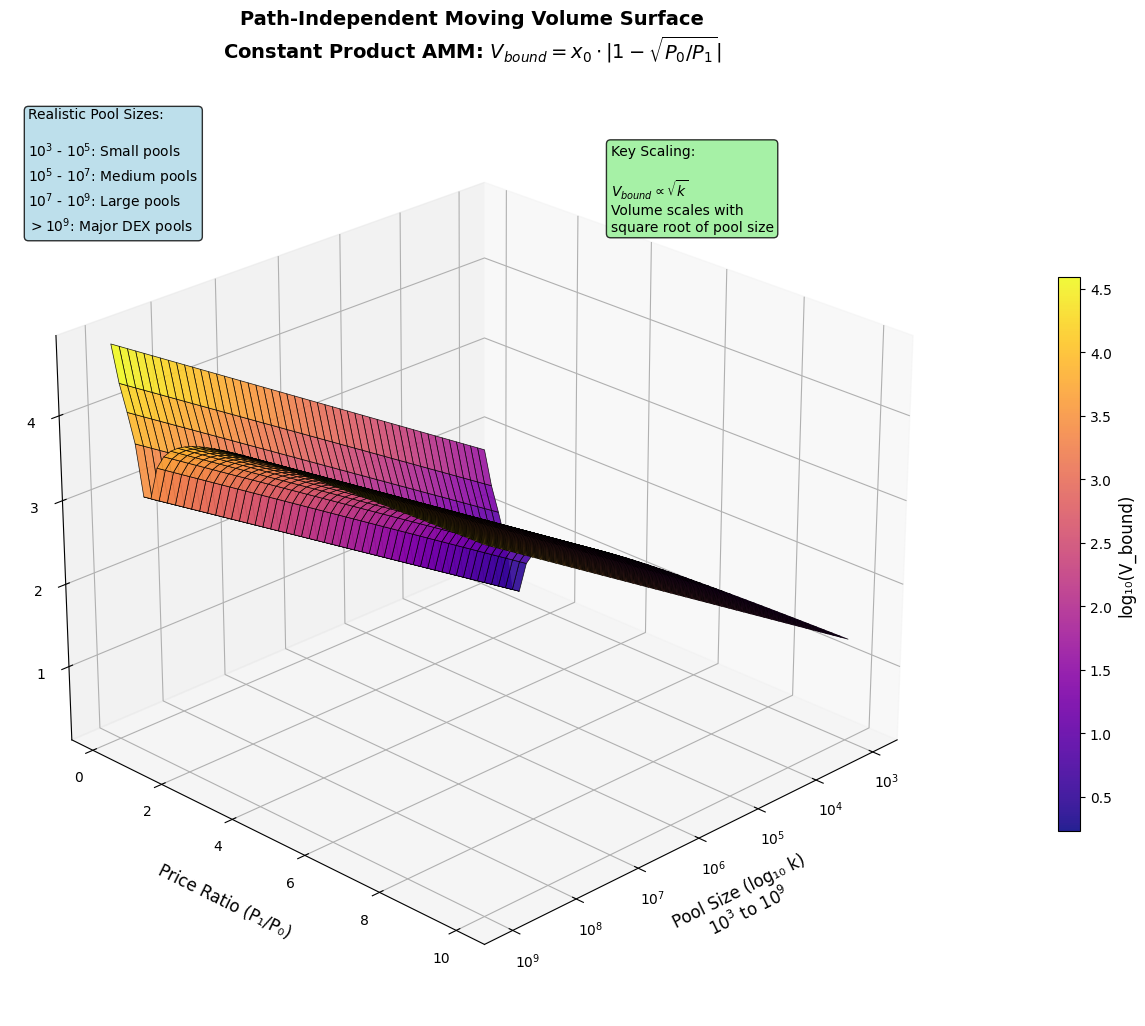

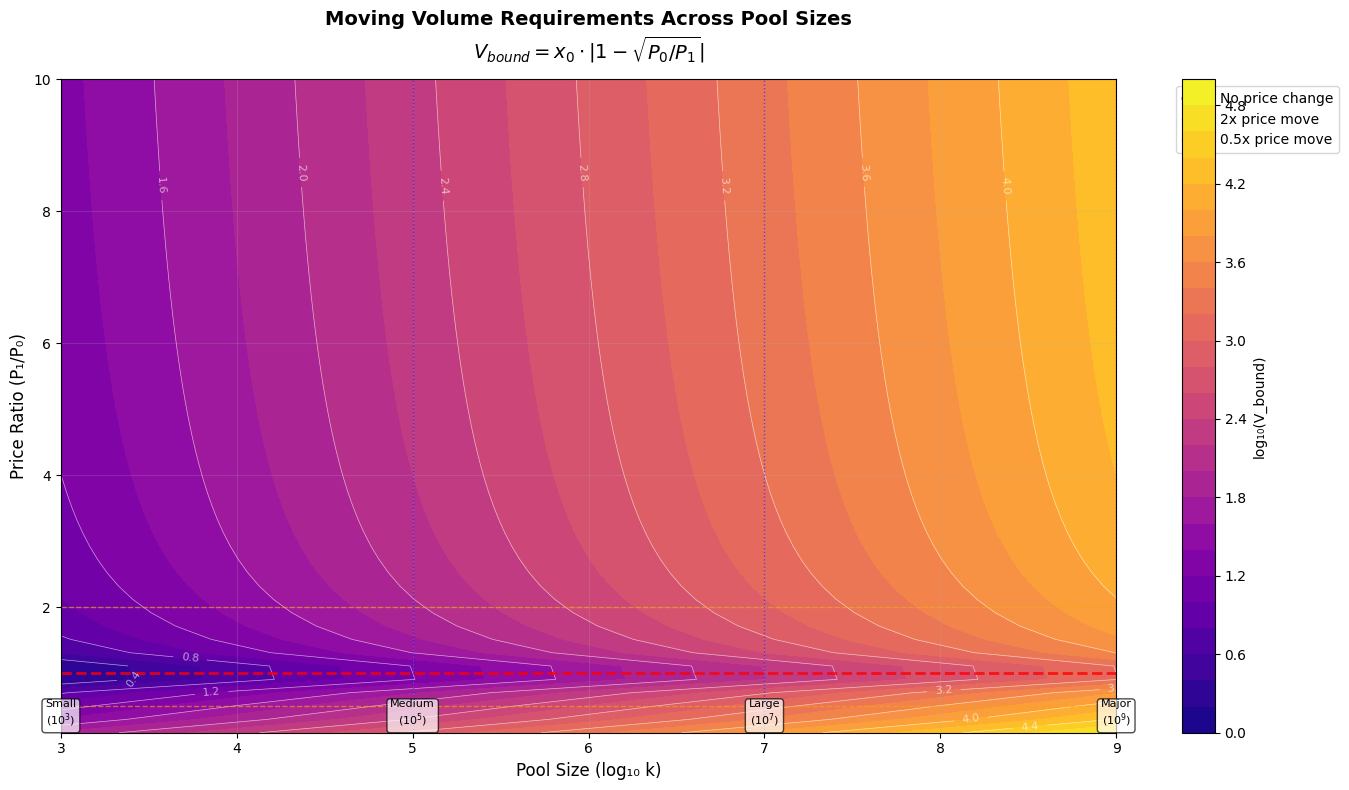

MOVING VOLUME ANALYSIS ACROSS POOL SIZES
Scenario                                 Pool Size    Price Δ    V_bound         % of Pool   
------------------------------------------------------------------------------------------
Very small pool, 10% price increase      1e+03        1.10      x 1               4.65      %
Very small pool, 2x price increase       1e+03        2.00      x 9               29.29     %
Medium pool, 10% price increase          1e+05        1.10      x 15              4.65      %
Medium pool, 2x price increase           1e+05        2.00      x 93              29.29     %
Large pool, 10% price increase           1e+07        1.10      x 147             4.65      %
Large pool, 2x price increase            1e+07        2.00      x 926             29.29     %
Major pool, 1% price increase            1e+09        1.01      x 157             0.50      %
Major pool, 10% price increase           1e+09        1.10      x 1472            4.65      %

KEY INSIGHTS:
• Small

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Create ranges for pool size (k) and price ratio - updated range
pool_sizes = np.logspace(3, 9, 50)  # k values from 1,000 to 1,000,000,000 (1B)
price_ratios = np.linspace(0.1, 10, 50)  # P₁/P₀ from 0.1x to 10x

# Create meshgrid
K, R = np.meshgrid(pool_sizes, price_ratios)

# Calculate V_bound surface
P0 = 1  # Normalize initial price to 1
V_bound_surface = np.sqrt(K / P0) * np.abs(1 - 1/np.sqrt(R))

# Create the 3D plot
fig = plt.figure(figsize=(16, 12))
ax = fig.add_subplot(111, projection='3d')

# Plot the surface
surface = ax.plot_surface(np.log10(K), R, np.log10(V_bound_surface),
                         cmap='plasma', alpha=0.9,
                         linewidth=0.5, antialiased=True, edgecolor='black')

# Customize the plot
ax.set_xlabel('Pool Size (log₁₀ k)\n$10^3$ to $10^9$', fontsize=12, labelpad=15)
ax.set_ylabel('Price Ratio (P₁/P₀)', fontsize=12, labelpad=15)
ax.set_zlabel('Moving Volume (log₁₀ V_bound)', fontsize=12, labelpad=15)
ax.set_title('Path-Independent Moving Volume Surface\nConstant Product AMM: $V_{bound} = x_0 \\cdot |1 - \\sqrt{P_0/P_1}|$',
             fontsize=14, fontweight='bold', pad=25)

# Add colorbar
cbar = fig.colorbar(surface, ax=ax, shrink=0.6, aspect=25, pad=0.1)
cbar.set_label('log₁₀(V_bound)', fontsize=12)

# Add annotations for realistic pool sizes
ax.text2D(0.02, 0.85, "Realistic Pool Sizes:\n\n"
          "$10^3$ - $10^5$: Small pools\n"
          "$10^5$ - $10^7$: Medium pools\n"
          "$10^7$ - $10^9$: Large pools\n"
          "$>10^9$: Major DEX pools",
          transform=ax.transAxes,
          bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.8),
          fontsize=10)

# Add mathematical insight
ax.text2D(0.65, 0.85, "Key Scaling:\n\n"
          "$V_{bound} \\propto \\sqrt{k}$\n"
          "Volume scales with\nsquare root of pool size",
          transform=ax.transAxes,
          bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.8),
          fontsize=10)

# Set better viewing angle
ax.view_init(elev=25, azim=45)

# Customize ticks for better readability
ax.set_xticks([3, 4, 5, 6, 7, 8, 9])
ax.set_xticklabels(['$10^3$', '$10^4$', '$10^5$', '$10^6$', '$10^7$', '$10^8$', '$10^9$'])

plt.tight_layout()
plt.show()

# Create a 2D contour plot for additional clarity
plt.figure(figsize=(14, 8))

# Create contour plot
contour = plt.contourf(np.log10(K), R, np.log10(V_bound_surface),
                      levels=25, cmap='plasma')
plt.colorbar(contour, label='log₁₀(V_bound)')

# Add contour lines
contour_lines = plt.contour(np.log10(K), R, np.log10(V_bound_surface),
                           levels=12, colors='white', alpha=0.6, linewidths=0.5)
plt.clabel(contour_lines, inline=True, fontsize=8, fmt='%.1f')

plt.xlabel('Pool Size (log₁₀ k)', fontsize=12)
plt.ylabel('Price Ratio (P₁/P₀)', fontsize=12)
plt.title('Moving Volume Requirements Across Pool Sizes\n$V_{bound} = x_0 \\cdot |1 - \\sqrt{P_0/P_1}|$',
          fontsize=14, fontweight='bold', pad=15)

# Add reference lines and annotations for common scenarios
plt.axhline(y=1, color='red', linestyle='--', alpha=0.8, linewidth=2, label='No price change')
plt.axhline(y=2, color='orange', linestyle='--', alpha=0.6, linewidth=1, label='2x price move')
plt.axhline(y=0.5, color='orange', linestyle='--', alpha=0.6, linewidth=1, label='0.5x price move')

# Add pool size reference lines
common_pools = {
    3: 'Small\n($10^3$)',
    5: 'Medium\n($10^5$)',
    7: 'Large\n($10^7$)',
    9: 'Major\n($10^9$)'
}

for log_k, label in common_pools.items():
    plt.axvline(x=log_k, color='blue', linestyle=':', alpha=0.5, linewidth=1)
    plt.text(log_k, 0.15, label, ha='center', va='bottom',
             bbox=dict(boxstyle='round', facecolor='white', alpha=0.7),
             fontsize=8)

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

# Print detailed examples across the new range
print("MOVING VOLUME ANALYSIS ACROSS POOL SIZES")
print("=" * 70)

scenarios = [
    (1e3, 1.1, "Very small pool, 10% price increase"),
    (1e3, 2.0, "Very small pool, 2x price increase"),
    (1e5, 1.1, "Medium pool, 10% price increase"),
    (1e5, 2.0, "Medium pool, 2x price increase"),
    (1e7, 1.1, "Large pool, 10% price increase"),
    (1e7, 2.0, "Large pool, 2x price increase"),
    (1e9, 1.01, "Major pool, 1% price increase"),
    (1e9, 1.1, "Major pool, 10% price increase")
]

print(f"{'Scenario':<40} {'Pool Size':<12} {'Price Δ':<10} {'V_bound':<15} {'% of Pool':<12}")
print("-" * 90)

for k, price_ratio, description in scenarios:
    x0 = np.sqrt(k)  # Since P₀ = 1
    V_bound = x0 * abs(1 - 1/np.sqrt(price_ratio))
    pool_percentage = (V_bound / x0) * 100

    print(f"{description:<40} {k:<12.0e} {price_ratio:<10.2f}x {V_bound:<15.0f} {pool_percentage:<10.2f}%")

print("\n" + "=" * 70)
print("KEY INSIGHTS:")
print("• Small pools (<$10^5$): Significant price moves with modest volume")
print("• Medium pools ($10^5$-$10^7$): Balanced liquidity and stability")
print("• Large pools (>$10^7$): Massive volume needed for price changes")
print("• All pools follow the same V_bound = x₀·|1-√(P₀/P₁)| relationship")
print("• Volume scales with √k - fundamental property of CPAMMs")

# Enhanced visualization with simulation overlay

Running comprehensive simulation experiment with 500 paths...
Generated 500 valid simulation results


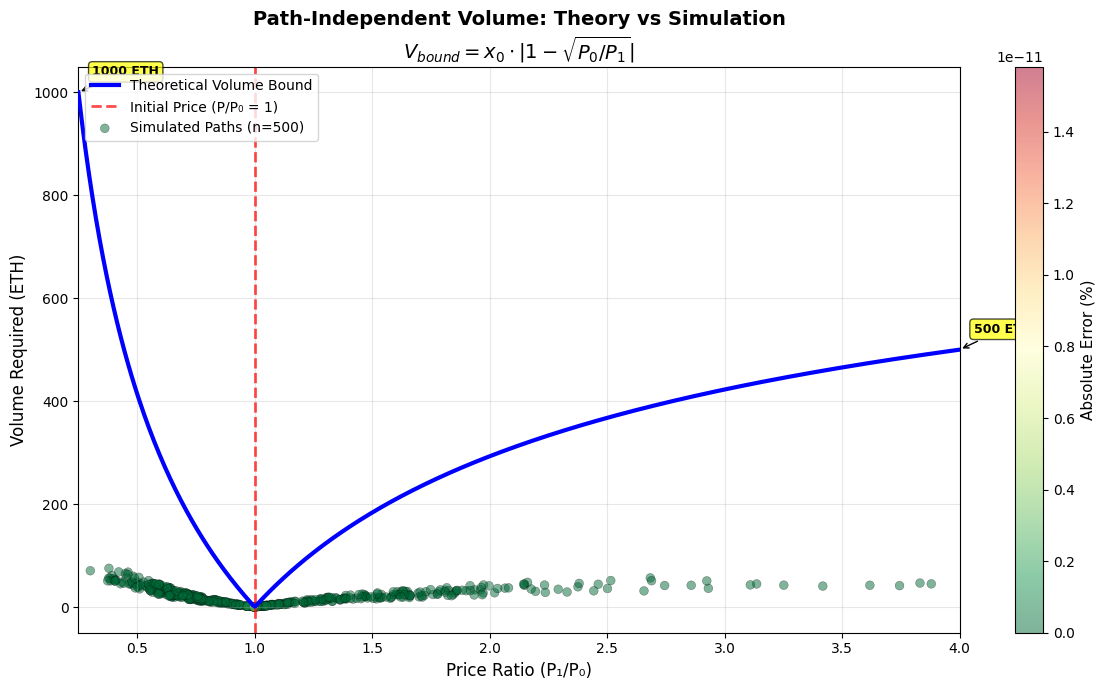


V_BOUND ACCURACY ANALYSIS - SUMMARY STATISTICS
Total Simulations: 500

Error Metrics:
  Mean Absolute Error: 0.000000 ETH
  Std Dev Error: 0.000000 ETH
  Mean % Error: 0.0000%
  Median % Error: 0.0000%
  95th Percentile Error: 0.0000%

Correlation: 1.000000

Accuracy Tolerance Bands:
  Within ±1%:  100.0%
  Within ±5%:  100.0%
  Within ±10%: 100.0%

KEY INSIGHT:
High correlation and tight error bounds confirm V_bound formula
accurately predicts volume required for price movements.



In [5]:
from automated_marketmaker_calc import VolumePathAnalysis

# Initialize the research visualization class with pool parameters
volume_analyzer = VolumePathAnalysis(x0=1000, P0=4000)

# Run AMM simulations to generate empirical data
# (Using the AMMSimulator and run_simulation_experiment from earlier in notebook)
print("Running comprehensive simulation experiment with 500 paths...")
simulation_results = run_simulation_experiment(num_simulations=500)
print(f"Generated {len(simulation_results)} valid simulation results")

# Create enhanced visualization: Theoretical line + Simulation scatter overlay
fig, ax = volume_analyzer.plot_theoretical_with_simulation_overlay(
    simulation_results=simulation_results,
    price_ratio_range=(0.25, 4.0),
    figsize=(12, 7),
    color_by='error_pct',  # Color points by estimation error
    alpha_scatter=0.5,
    scatter_size=40,
    save_path=None  # Set to filename to save, e.g., 'volume_theory_vs_sim.png'
)

plt.show()

# Print summary statistics
volume_analyzer.print_summary(simulation_results)

# Error distribution and accuracy analysis

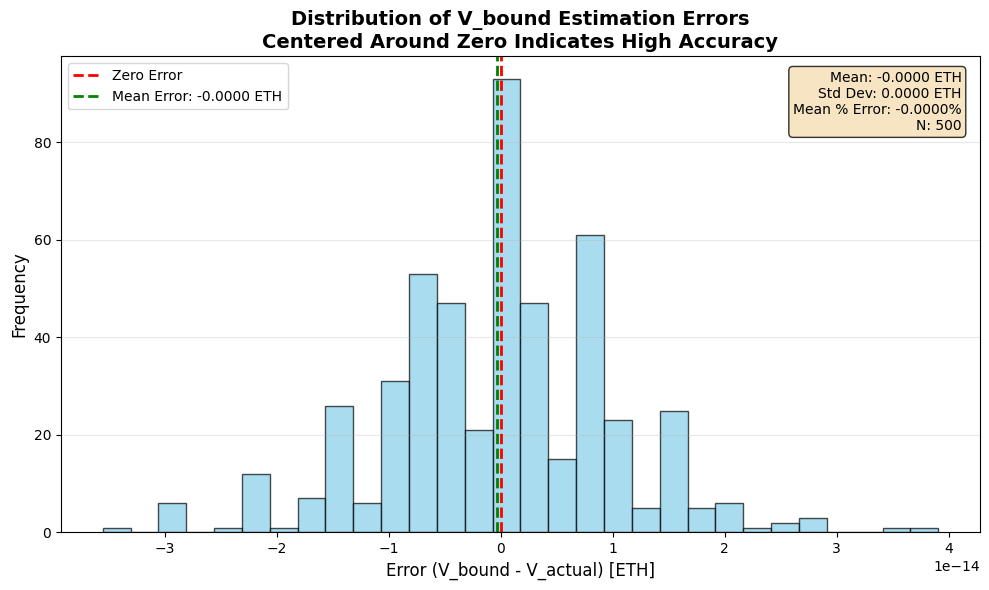

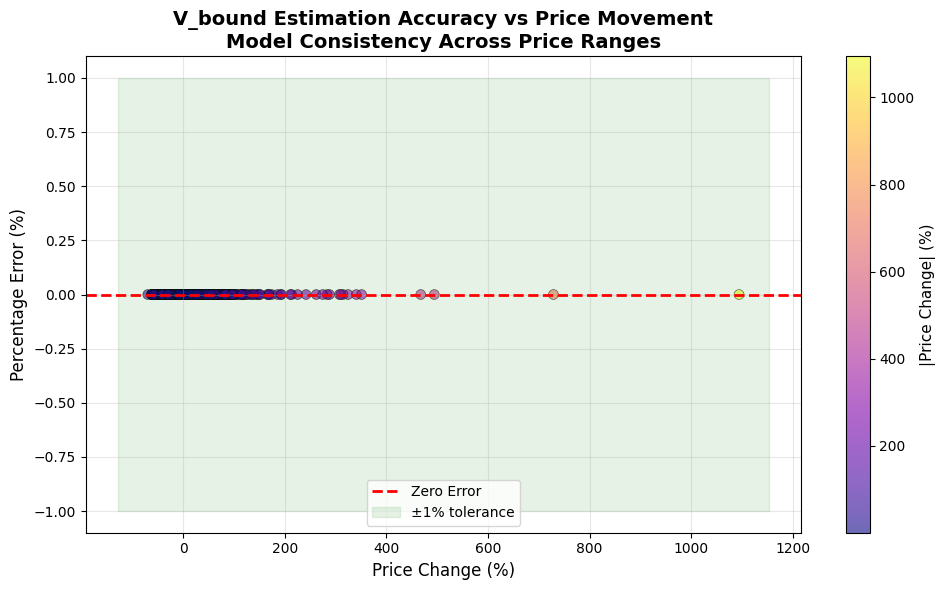

In [6]:
# Plot 2: Error distribution histogram
fig2, ax2 = volume_analyzer.plot_error_distribution(
    simulation_results=simulation_results,
    figsize=(10, 6),
    bins=30,
    save_path=None
)
plt.show()

# Plot 3: Accuracy vs price movement
fig3, ax3 = volume_analyzer.plot_accuracy_vs_price_movement(
    simulation_results=simulation_results,
    figsize=(10, 6),
    save_path=None
)
plt.show()

# Integration with Payoff simulations (for calibrated_prices.ipynb)

In [7]:
"""
EXAMPLE: How to use VolumePathAnalysis with Payoff pipeline results from calibrated_prices.ipynb

This shows the integration pattern for the research paper visualization.
In calibrated_prices.ipynb, after running Payoff.pipeline(), you can extract
simulation results and validate them against the theoretical V_bound formula.
"""

# WORKFLOW FOR calibrated_prices.ipynb:
# =========================================

# Step 1: After running Payoff.pipeline() and getting paths_df:
# (Pseudocode - adapt to your actual payoff results)
"""
# In calibrated_prices.ipynb:
from automated_marketmaker_calc import Payoff, VolumePathAnalysis

payoff = Payoff()
payoff.pipeline(
    pool_fee=0.01,
    amount_x_pool_t0=1000,
    amount_y_pool_t0=10000,
    total_investment_x=100,
    FX_timeseries=simulated_prices,
    volume_timeseries=simulated_volumes,
    max_paths=500,
    fee_split=0.5,
    use_volume_decomposition=False,
    drop_insufficient_volume=False
)

# Step 2: Extract simulation data from paths_df
paths_df = payoff.paths_df

# Convert paths_df to format compatible with VolumePathAnalysis
simulation_results = []
for idx, row in paths_df.iterrows():
    P0 = row['FX_t0']  # Initial price
    P1 = row['FX_tN']  # Final price
    V_actual = row['V_total_vol']  # Actual volume from simulation
    
    # Calculate theoretical bound
    V_bound = row['amount_x_pool_t0'] * abs(1 - np.sqrt(P0 / P1))
    
    simulation_results.append({
        'P0': P0,
        'P1': P1,
        'price_change_pct': (P1 - P0) / P0 * 100,
        'V_bound': V_bound,
        'V_actual': V_actual,
        'error': V_bound - V_actual,
        'error_pct': ((V_bound - V_actual) / V_actual * 100) if V_actual != 0 else 0,
    })

# Step 3: Create visualization
volume_analyzer = VolumePathAnalysis(x0=row['amount_x_pool_t0'], P0=P0)

fig, ax = volume_analyzer.plot_theoretical_with_simulation_overlay(
    simulation_results=simulation_results,
    price_ratio_range=(0.5, 2.0),  # Adjust for your price ranges
    color_by='error_pct',
    save_path='volume_analysis_payoff.png'
)

# Step 4: Print validation statistics
volume_analyzer.print_summary(simulation_results)
"""

print("=" * 70)
print("INTEGRATION GUIDE FOR calibrated_prices.ipynb")
print("=" * 70)
print("\n1. IMPORT the visualization class:")
print("   from automated_marketmaker_calc import VolumePathAnalysis")
print("\n2. RUN payoff pipeline to get paths_df")
print("\n3. EXTRACT simulation data from paths_df:")
print("   - P0 = row['FX_t0']")
print("   - P1 = row['FX_tN']")
print("   - V_actual = row['V_total_vol']")
print("\n4. CALCULATE theoretical V_bound for each path")
print("\n5. CREATE visualization:")
print("   analyzer = VolumePathAnalysis(x0=x0, P0=P0)")
print("   fig, ax = analyzer.plot_theoretical_with_simulation_overlay(...)")
print("\n6. VALIDATE with summary statistics:")
print("   analyzer.print_summary(simulation_results)")
print("=" * 70 + "\n")


INTEGRATION GUIDE FOR calibrated_prices.ipynb

1. IMPORT the visualization class:
   from automated_marketmaker_calc import VolumePathAnalysis

2. RUN payoff pipeline to get paths_df

3. EXTRACT simulation data from paths_df:
   - P0 = row['FX_t0']
   - P1 = row['FX_tN']
   - V_actual = row['V_total_vol']

4. CALCULATE theoretical V_bound for each path

5. CREATE visualization:
   analyzer = VolumePathAnalysis(x0=x0, P0=P0)
   fig, ax = analyzer.plot_theoretical_with_simulation_overlay(...)

6. VALIDATE with summary statistics:
   analyzer.print_summary(simulation_results)

